In [2]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import itertools as itr
import numpy as np
from sklearn.metrics import mean_squared_error
from random import randrange
from datetime import datetime
import json

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.func import functional_call, vmap, vjp, jvp, grad

from scipy.linalg import svdvals, norm
from scipy.special import softmax
from scipy.optimize import minimize_scalar

from common.const import DATASET_PATH
from common.util import *
#from common.ffn_model.minst.ffn_minst_optimise_old import NTKCalculator
from common.ffn_model.minst.ffn_minst_util import MetaData
from common.ffn_model.minst.ffn_minst_optimise \
    import StepCalculatorBase #, StepCalculatorEtaNtk, StepCalculatorEtaAveragedNtk
from common.ffn_model.minst.ffn_minst_relu import MNISTReLU

from torchvision.datasets import EMNIST
#from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid

import logging

In [3]:
class NTKCalculator:
    def __init__(self, meta):
        self.meta = meta
        self.input_dweight = np.zeros((meta.output_dim, meta.batch_size, meta.input_width, meta.input_dim))
        self.input_dbias = np.zeros((meta.output_dim, meta.batch_size, meta.input_width))
        self.hidden_dweight = np.zeros((meta.output_dim, meta.batch_size, meta.hidden_width, meta.input_width))
        self.hidden_dbias = np.zeros((meta.output_dim, meta.batch_size, meta.hidden_width))
        self.output_dweight = np.zeros((meta.output_dim, meta.batch_size, meta.output_dim, meta.hidden_width))
        self.output_dbias = np.zeros((meta.output_dim, meta.batch_size, meta.output_dim))

    def calculate_derivatives(self, testNet, logits):
        for kk, alpha in itr.product(range(self.meta.output_dim), range(self.meta.batch_size)):
            df = torch.autograd.grad(logits[alpha,kk], (testNet.input_fc.weight, testNet.input_fc.bias\
                                            , testNet.hidden_fc.weight, testNet.hidden_fc.bias\
                                            , testNet.output_fc.weight, testNet.output_fc.bias)\
                , retain_graph=True, create_graph=True, allow_unused=True)
            self.input_dweight[kk, alpha] = df[0].detach().numpy()
            self.input_dbias[kk, alpha] = df[1].detach().numpy()
            self.hidden_dweight[kk, alpha] = df[2].detach().numpy()
            self.hidden_dbias[kk, alpha] = df[3].detach().numpy()
            self.output_dweight[kk, alpha] = df[4].detach().numpy()
            self.output_dbias[kk, alpha] = df[5].detach().numpy()

    def calculate_average_NTK(self, HL):
        meta = self.meta
        HL_avg = np.zeros((meta.batch_size, meta.batch_size))
        for alpha1, alpha2 in itr.product(range(meta.batch_size), range(meta.batch_size)):
            value_avg = np.average([HL[num, num, alpha1, alpha2] for num in np.arange(meta.output_dim)])
            HL_avg[alpha1, alpha2] = value_avg

        return HL_avg

    def calculate_NTK(self):
        meta = self.meta
        input_dbias_sum = meta.lb * np.tensordot(self.input_dbias, self.input_dbias, axes=([2],[2]))
        input_dweight_sum = meta.lw_input() * np.tensordot(self.input_dweight, self.input_dweight, axes=([2,3],[2,3]))
        hidden_dbias_sum = meta.lb * np.tensordot(self.hidden_dbias, self.hidden_dbias, axes=([2],[2]))
        hidden_dweight_sum = meta.lw_hidden() * np.tensordot(self.hidden_dweight, self.hidden_dweight, axes=([2,3],[2,3]))        
        output_dbias_sum = meta.lb * np.tensordot(self.output_dbias, self.output_dbias, axes=([2],[2]))
        output_dweight_sum = meta.lw_output() * np.tensordot(self.output_dweight, self.output_dweight, axes=([2,3],[2,3]))        
        summary = input_dbias_sum+input_dweight_sum+hidden_dbias_sum+hidden_dweight_sum+output_dbias_sum+output_dweight_sum
        return np.moveaxis(summary, 1, 2)
    
    def calculate_ID(self):
        meta = self.meta
        ID = np.zeros((meta.output_dim, meta.output_dim, meta.batch_size, meta.batch_size))
        for kk, alpha in itr.product(range(meta.output_dim), range(meta.output_dim)):
            ID[kk, kk, alpha, alpha] = 1
        return ID

##Step calculates η minimising (∞.86) with NTK-averaging and 2-matrix norm. Parameters change is according to (7.11)
class StepCalculatorEtaAveragedNtk(StepCalculatorBase):
    def __init__(self, meta, ntk_recalc_steps_period = 5):
        super().__init__()
        self.meta = meta
        self.ntk_recalc_steps_period = ntk_recalc_steps_period

    def step(self, testNet, labels, logits, etas):
        meta = self.meta

        calc0 = NTKCalculator(meta)
        calc0.calculate_derivatives(testNet, logits)
        do_calc_eta = (etas[0] == 0.0 or self.ntk_recalc_steps_period <= 0)
        if (do_calc_eta == False):
            do_calc_eta = randrange(self.ntk_recalc_steps_period) == 0

        HL = None
        eta = 0.0
        if (do_calc_eta):
            logging.info("##Calculating NTK by (8.4)")
            HL = calc0.calculate_NTK()
            HL_avg = calc0.calculate_average_NTK(HL)
            ID = np.identity(meta.batch_size)
            logging.info("##Calculating η minimising (∞.86): HL_avg = {}".format(HL_avg))
            fun = lambda eta: norm(ID - eta*HL_avg, ord=2) #np.inf)
            res = minimize_scalar(fun, bounds=(0, 1000))
            logging.info("##Optimal point found: {}".format(res))
            if etas[0] == 0.0:
                etas[1] = res.x
            else:
                etas[1] = etas[0]
            etas[0] = res.x
            eta = res.x
        else:
            eta = round(0.6 * etas[0] + 0.4 * etas[1], 5);
            logging.info("##Using previous eta value={}".format(eta))
        #(7.11)
        logits_detached = logits.detach()
        yy = labels_to_onehot(logits_detached, labels)

        #print("Calculating deltas")
        zz = np.transpose(logits_detached.numpy())
        term = eta*(yy - zz)
        self.delta_weight_00 = torch.from_numpy(np.tensordot(term, calc0.input_dweight, axes=([0,1],[0,1])) * meta.lw_input())
        self.delta_bias_00 = torch.from_numpy(np.tensordot(term, calc0.input_dbias, axes=([0,1],[0,1])) * meta.lb)
        self.delta_weight_01 = torch.from_numpy(np.tensordot(term, calc0.hidden_dweight, axes=([0,1],[0,1])) * meta.lw_hidden())
        self.delta_bias_01 = torch.from_numpy(np.tensordot(term, calc0.hidden_dbias, axes=([0,1],[0,1])) * meta.lb)
        self.delta_weight_02 = torch.from_numpy(np.tensordot(term, calc0.output_dweight, axes=([0,1],[0,1])) * meta.lw_output())
        self.delta_bias_02 = torch.from_numpy(np.tensordot(term, calc0.output_dbias, axes=([0,1],[0,1])) * meta.lb)
        
        self.do_step0(testNet)
        #self.ntk_latest_calculated = HL
        return etas, HL
    
##Step calculates η minimising (∞.86) with 2-matrix norm. Parameters change is according to (7.11)
class StepCalculatorEtaNtk(StepCalculatorBase):
    def __init__(self, meta, ntk_recalc_steps_period = 5):
        super().__init__()
        self.meta = meta
        self.ntk_recalc_steps_period = ntk_recalc_steps_period

    def step(self, testNet, labels, logits, etas):
        meta = self.meta
        logits_detached = logits.detach()
        yy = labels_to_onehot(logits_detached, labels)
        zz = np.transpose(logits_detached.numpy())
        delta = zz - yy

        calc0 = NTKCalculator(meta)
        calc0.calculate_derivatives(testNet, logits)
        do_calc_eta = (etas[0] == 0.0 or self.ntk_recalc_steps_period <= 0)
        if (do_calc_eta == False):
            do_calc_eta = randrange(self.ntk_recalc_steps_period) == 0

        HL = None
        eta = 0.0
        if (do_calc_eta):
            logging.info("##Calculating NTK by (8.4)")
            HL = calc0.calculate_NTK()
            ID = calc0.calculate_ID()
            logging.info("##Calculating η minimising (∞.86)")
            fun = lambda eta: norm(np.tensordot(ID - eta*HL, delta, axes=([1,3],[0,1])), ord='fro')
            res = minimize_scalar(fun, bounds=(0, 1000))
            logging.info("##Optimal point found: {}".format(res))
            logging.info("##Step ratio: {}".format(res.fun/norm(delta, ord='fro')))
            if etas[0] == 0.0:
                etas[1] = res.x
            else:
                etas[1] = etas[0]
            etas[0] = res.x
            eta = res.x
        else:
            eta = round(0.6 * etas[0] + 0.4 * etas[1], 5);
            logging.info("##Using previous eta value={}".format(eta))
        #(7.11)

        term = -1*eta*delta
        self.delta_weight_00 = np.tensordot(term, calc0.input_dweight, axes=([0,1],[0,1])) * meta.lw_input()
        self.delta_bias_00 = np.tensordot(term, calc0.input_dbias, axes=([0,1],[0,1])) * meta.lb
        self.delta_weight_01 = np.tensordot(term, calc0.hidden_dweight, axes=([0,1],[0,1])) * meta.lw_hidden()
        self.delta_bias_01 = np.tensordot(term, calc0.hidden_dbias, axes=([0,1],[0,1])) * meta.lb
        self.delta_weight_02 = np.tensordot(term, calc0.output_dweight, axes=([0,1],[0,1])) * meta.lw_output()
        self.delta_bias_02 = np.tensordot(term, calc0.output_dbias, axes=([0,1],[0,1])) * meta.lb
        
        self.do_step0(testNet)
        return etas, HL


In [4]:
logging.basicConfig(filename="log_convcrity_step_softmax_loss_eminst_v2.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")
                #datefmt="%Y-%m-%d %H:%M:%S,%(msecs)")
                #datefmt="%d/%m/%Y %I:%M:%S")


#### MNIST dataset

MNIST dataset is used which contains 60000 28x28 images of handwritten digits from 0 to 9. 

In [5]:
# use it to conver from PIL to torch.Tensor
image_transform = ToTensor()

train_dataset = EMNIST(root=DATASET_PATH, split='letters', train=True, download=True, transform=image_transform)
test_dataset = EMNIST(root=DATASET_PATH, split='letters', train=False, download=True, transform=image_transform)
#train_dataset = MNIST(root=DATASET_PATH, train=True, download=True, transform=image_transform)
#test_dataset = MNIST(root=DATASET_PATH, train=False, download=True, transform=image_transform)

In [6]:
BATCH_SIZE = 128 #96 #192 #96 #96 #128 #64 #

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
)

Data example:

In [7]:
INPUT_DIM = 28 * 28
OUTPUT_DIM = 26 #26  # num of classes

INPUT_WIDTH, HIDDEN_WIDTH = 1000, 400 #2000, 800 #1024, 128 #1000, 400 #500, 200 #1000, 400 #500, 200 #250, 100

lb, lw = 1e-2, 7.5 #1e-2,1,1 #1e-2, 1e-2, 1
meta = MetaData(input_dim = INPUT_DIM, input_width = INPUT_WIDTH, hidden_width = HIDDEN_WIDTH, output_dim = OUTPUT_DIM\
                , batch_size = BATCH_SIZE, lb = lb, lw = lw)

DEVICE = torch.device('cpu')  # change to `cuda:0` when available


##### UTILS

In [8]:
def save_dict(dict, dir):
    with open(dir + "/history.json", "w") as ff:
        ff.write(json.dumps(dict))
        ff.close()

def load_dict(dir):
    with open(dir + "/history.json", "r") as ff:
        dict = json.load(ff)
        ff.close()
        return dict

def flatten2d(HL):  #HL - [output_dim, output_dim, batch_size, batch_size]
    tmp = np.moveaxis(HL, 1, 2)
    dim = tmp.shape
    return np.reshape(tmp, (dim[0]*dim[1], dim[2]*dim[3]))

def NTK_softmaxV2(HL, qq, meta):
    SM = (np.identity(meta.output_dim)[:,:,None] - qq[:,None,:])*qq[None,:,:]
    return np.sum(SM[None,:,:,None,:]*HL[:,:,None,:,:], axis=1)

def NTK_softmaxV3(HL, qq, meta):
    SM = (np.identity(meta.output_dim)[:,:,None] - qq[:,None,:])*qq[None,:,:]
    return np.sum(SM[:,:,:]*HL[:,None,:], axis=0)

def reduce_tensor_to_active(TS_FULL, pp):
    return np.sum(TS_FULL[:,:,:,:]*pp[None,:,None,:], axis = 1)

def reduce_to_active(MX_FULL, pp):
    return np.sum(MX_FULL*pp, axis=0)

def calculate_ID(meta):
    ID = np.zeros((meta.output_dim, meta.output_dim, meta.batch_size, meta.batch_size))
    for kk, alpha in itr.product(range(meta.output_dim), range(meta.output_dim)):
        ID[kk, kk, alpha, alpha] = 1
    return ID

def visualise(history_params):
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes[0, 0].set_title('Loss (cross-entropy)')
    axes[0, 0].plot(history_params['train_loss'], label='Train Loss')
    axes[0, 0].plot(history_params['test_loss'], label='Test Loss')
    axes[0, 0].grid()
    axes[0, 0].legend(fontsize=20)
    
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].plot(history_params['train_accuracy'], label='Train Accuracy')
    axes[0, 1].plot(history_params['test_accuracy'], label='Test Accuracy')
    axes[0, 1].grid()
    axes[0, 1].legend(fontsize=20)

    axes[1, 0].set_title('Train-step eta')
    axes[1, 0].plot(history_params['train_eta'])
    axes[1, 0].grid()
    #ax2.legend(fontsize=20)

    axes[1, 1].set_title('Singular values for flattened NTK')
    #axes[1, 1].plot(history_params['ntk_sungular_min'], label='Singular min value')
    axes[1, 1].plot(history_params['train_ntk_sungular_max'], label='Singular max value')
    axes[1, 1].grid()
    axes[1, 1].legend(fontsize=20)
    
    plt.show()


In [9]:
# New method. Computes sum_{j,b} H_{i,j,a,b} v_{j,b}. Contributed by Zhang Allan
def ntkvp_np(func, params, x1, x2, delta, lbd_dict=None):
    '''
    lbd_dict: dict ~ {param_name: lambda},
        if None, all lambda = 1
    v ~ (n_samples * output_dim)
    x1, x2 ~ (n_samples * input_dim)
    '''
    v = torch.from_numpy(np.transpose(delta))
    def get_vjp(x2, v):
        def func_x2(params):
            return func(params, x2)

        output, vjp_fn = vjp(func_x2, params)

        # This computes vec @ J(x2).T
        # vec is some unit vector (a single slice of the Identity matrix)
        vjps = vjp_fn(v)

        return vjps
    vjps = vmap(get_vjp, (0, 0))(x2, v)
    if lbd_dict is None:
        for pn in vjps[0]:
            vjps[0][pn] = vjps[0][pn].sum(axis=0)
    else:
        for pn in vjps[0]:
            vjps[0][pn] = vjps[0][pn].sum(axis=0) * lbd_dict.get(pn, 1.)
    def get_ntkv(x1, vjps):
        def func_x1(params):
                return func(params, x1)
        # This computes J(X1) @ vjps
        _, jvps = jvp(func_x1, (params,), vjps)
        return jvps

    result = vmap(get_ntkv, (0, None))(x1, vjps)
    return np.transpose(result.detach().numpy())

def solve_eta_norm2(delta_r, delta):
    '''
    get eta which minimizes rhs of \inf.86
    delta_r, delta ~ (n_samples, n_outputs)
    delta: p - q
    delta_r: R_ab
    '''
    return np.sum((delta*delta_r)) / np.sum((delta_r**2))


<>:39: SyntaxWarning: invalid escape sequence '\i'
<>:39: SyntaxWarning: invalid escape sequence '\i'
C:\Users\vkmbo_dxc472\AppData\Local\Temp\ipykernel_21144\222394173.py:39: SyntaxWarning: invalid escape sequence '\i'
  '''


In [10]:
# Faster version of ntkvp. Computes sum_{j,b} H_{i,j,a,b} v_{j,b}. Contributed by Zhang Allan
def ntkvp2_np(func_single, func_mul, params, x1, x2, delta, lbd_dict=None):
    '''
    lbd_dict: dict ~ {param_name: lambda},
        if None, all lambda = 1
    v ~ (n_samples * output_dim)
    x1, x2 ~ (n_samples * input_dim)
    '''
    v = torch.from_numpy(np.transpose(delta))
    vjps = grad(lambda pa: (func_mul(pa, x2)*v).sum())(params)
    if lbd_dict is not None:
        for pn in vjps:
            vjps[pn] *= lbd_dict.get(pn, 1.)
    vjps = (vjps,)
    def get_ntkv(x1, vjps):
        def func_x1(params):
                return func_single(params, x1)
        # This computes J(X1) @ vjps
        _, jvps = jvp(func_x1, (params,), vjps)
        return jvps

    result = vmap(get_ntkv, (0, None))(x1, vjps)
    #return result
    return np.transpose(result.detach().numpy())


In [11]:
class StepCalculatorDeltas(StepCalculatorBase):
    def __init__(self, meta):
        super().__init__()
        self.meta = meta
        self.step_one = 1.0
        self.step_deltas = [0.0, -0.5, -0.25, -0.125, -0.0625, -0.03125, -0.015625]
        #Armiho: Loss(θ+α) <= c1*α*∇Loss(θ) + Loss(θ)
        #Wolf: |∇Loss(θ+α)| <= c2*|∇Loss(θ)|
        #0<c1<c2<1
        #Additional condition: ∇Loss(θ+α) <= c3*|∇Loss(θ)| , 0<c3<1 (Significant loss growth at the final point is unacceptable)
        self.c1 = 0.0 #0.000000005 #0.000005 #0.000025
        self.c2 = 0.99 #0.75 #0.5#
        self.c3 = 0.25

    def calculate_deltas(self, testNet, loss, eta):
        meta = self.meta
        df = torch.autograd.grad(loss, (testNet.input_fc.weight, testNet.input_fc.bias\
                                        , testNet.hidden_fc.weight, testNet.hidden_fc.bias\
                                        , testNet.output_fc.weight, testNet.output_fc.bias)\
            , retain_graph=True, create_graph=True, allow_unused=True)
        self.delta_weight_00 = -eta * meta.lw_input() * df[0].detach() #.numpy()
        self.delta_bias_00 = -eta * meta.lb *df[1].detach() #.numpy()
        self.delta_weight_01 = -eta * meta.lw_hidden() *df[2].detach() #.numpy()
        self.delta_bias_01 = -eta * meta.lb *df[3].detach() #.numpy()
        self.delta_weight_02 = -eta * meta.lw_output() *df[4].detach() #.numpy()
        self.delta_bias_02 = -eta * meta.lb *df[5].detach() #.numpy()

    #Armiho: Loss(θ+α) <= c1*α*∇Loss(θ) + Loss(θ)
    #Wolf: |∇Loss(θ+α)| <= c2*|∇Loss(θ)|
    #0<c1<c2<1
    #Additional condition: ∇Loss(θ+α) <= c3*|∇Loss(θ)| , 0<c3<1 (Significant loss growth at the final point is unacceptable)
    def backtrack_armiho_wolf_additional(self, testNet, xx, pp, qq, eta):
        initialLoss = -np.sum(pp * np.log(qq))/meta.batch_size
        ratio = reduce_to_active(pp/qq, pp)
        logging.info("##Initial loss = {}".format(initialLoss))

        with torch.no_grad():
            self.do_step0(testNet, self.step_one)
            logits_one = testNet.forward_(xx)
            qq_one = softmax(np.transpose(logits_one.detach().numpy()), axis=(0))
            delta_delta_one = reduce_to_active(qq - qq_one, pp) #We consider pp/qq without -

        logits_k = None
        aa = self.step_one
        with torch.no_grad():
            for step_delta in self.step_deltas:
                if (step_delta != 0.0):
                    aa += step_delta
                    self.do_step0(testNet, step_delta)
                logits_k = testNet.forward_(xx)
                qq_k = softmax(np.transpose(logits_k.detach().numpy()), axis=(0))
                #logging.info("qq1 factual: {}".format(reduce_to_active(qq_k, pp)))
                loss_k = -np.sum(pp * np.log(qq_k))/meta.batch_size
                ratio_k = reduce_to_active(pp/qq_k, pp)
                #diff_est_k = np.dot(ratio_k, delta_delta_est) #∇L(θ+α)
                logging.info("##Step with aa: {}, loss_k: {}".format(aa, loss_k))
                qq_k_reduced = reduce_to_active(qq_k, pp)
                logging.info("##Factual qq_k for ones: min={}, max={}, avg={}"\
                             .format(np.min(qq_k_reduced), np.max(qq_k_reduced), np.average(qq_k_reduced)))
                
                diff_fact = np.dot(ratio, delta_delta_one)
                diff_fact_k = np.dot(ratio_k, delta_delta_one)
                pq_ratio_k = norm(pp - qq_k, ord=2)/norm(pp - qq, ord=2)
                logging.info("##With factual qq_k: diff_init = {}, diff_k = {}, (p-q)ratio norm-2: {}"\
                            .format(diff_fact, diff_fact_k, pq_ratio_k))
                condition_armiho = loss_k <= initialLoss + self.c1*aa*diff_fact
                condition_wolf = abs(diff_fact_k) <= self.c2*abs(diff_fact)
                condition_additional = diff_fact_k <= self.c3*abs(diff_fact)
                logging.info("##Conditions: armiho = {}, wolf = {}, additional = {}, "\
                             .format(condition_armiho, condition_wolf, condition_additional))
                if condition_armiho and condition_wolf and condition_additional:
                    break

        return eta*aa, logits_k

##Step calculates η minimising (∞.86) softmax-analogue with 2-matrix norm. 
## Parameters change is according to (7.11) for cross-enthropy loss, step is adjusted by Armiho/Wolf condition
class StepCalculatorEtaSoftmaxArmihoNorm2(StepCalculatorDeltas):
    def __init__(self, meta):
        super().__init__(meta)
        self.lbd_dict = {}
        self.lbd_dict['input_fc.weight'] = meta.lw_input()
        self.lbd_dict['hidden_fc.weight'] = meta.lw_hidden()
        self.lbd_dict['output_fc.weight'] = meta.lw_output()
        self.lbd_dict['input_fc.bias'] = meta.lb
        self.lbd_dict['hidden_fc.bias'] = meta.lb
        self.lbd_dict['output_fc.bias'] = meta.lb
        self.criterion = nn.CrossEntropyLoss(reduction='sum')


    def step(self, testNet, logits_detached, labels, xx):
        meta = self.meta
        USE_LOSS = True

        pp = labels_to_softhot(labels, meta.output_dim)
        qq = softmax(np.transpose(logits_detached), axis=(0))
        delta = pp - qq
        delta0 = reduce_to_active(delta, pp)

        logging.info("##Calculating reduced NTK")
        params = {k: v.detach() for k, v in testNet.named_parameters()}
        #fnet_single = lambda params, xx: functional_call(testNet, params, xx)
        fnet_single = lambda params, x: functional_call(testNet, params, (x.unsqueeze(0),)).squeeze(0)
        fnet_mul = lambda params, x: functional_call(testNet, params, (x,))
        #Reduced NTK
        #delta_r = ntkvp_np(fnet_single, params, xx, xx, delta, self.lbd_dict)
        delta_r = ntkvp2_np(fnet_single, fnet_mul, params, xx, xx, delta, self.lbd_dict)

        logging.info("##Calculating step-forward and eta")
        testNet.zero_grad()
        logits = testNet.forward_(xx)
        NL_r = NTK_softmaxV3(delta_r, qq, meta)
        delta0_r = reduce_to_active(NL_r, pp)
        eta = solve_eta_norm2(NL_r, delta) #for all n,α
        eta_ones = solve_eta_norm2(delta0_r, delta0) #for each α only n with pp=1 is taken
        logging.info("##Calculated eta for ones = {}, general eta = {}".format(eta_ones, eta))
        logging.info("##Calculating derivatives")
        if (USE_LOSS):
            loss = self.criterion(logits, labels)
            self.calculate_deltas(testNet, loss, eta)
        else:
            calc0 = NTKCalculator(meta)
            calc0.calculate_derivatives(testNet, logits)
            term = eta*delta
            self.delta_weight_00 = np.tensordot(term, calc0.input_dweight, axes=([0,1],[0,1])) * meta.lw_input()
            self.delta_bias_00 = np.tensordot(term, calc0.input_dbias, axes=([0,1],[0,1])) * meta.lb
            self.delta_weight_01 = np.tensordot(term, calc0.hidden_dweight, axes=([0,1],[0,1])) * meta.lw_hidden()
            self.delta_bias_01 = np.tensordot(term, calc0.hidden_dbias, axes=([0,1],[0,1])) * meta.lb
            self.delta_weight_02 = np.tensordot(term, calc0.output_dweight, axes=([0,1],[0,1])) * meta.lw_output()
            self.delta_bias_02 = np.tensordot(term, calc0.output_dbias, axes=([0,1],[0,1])) * meta.lb

        return self.backtrack_armiho_wolf_additional(testNet, xx, pp, qq, eta)


In [12]:
##Step calculates η minimising (∞.86) softmax-analogue with 1-matrix norm. 
## Parameters change is according to (7.11) for cross-enthropy loss, step is adjusted by Armiho/Wolf condition
class StepCalculatorEtaSoftmaxArmihoNorm1(StepCalculatorDeltas):
    def __init__(self, meta):
        super().__init__(meta)
        self.meta = meta
        self.lbd_dict = {}
        self.lbd_dict['input_fc.weight'] = meta.lw_input()
        self.lbd_dict['hidden_fc.weight'] = meta.lw_hidden()
        self.lbd_dict['output_fc.weight'] = meta.lw_output()
        self.lbd_dict['input_fc.bias'] = meta.lb
        self.lbd_dict['hidden_fc.bias'] = meta.lb
        self.lbd_dict['output_fc.bias'] = meta.lb        
        self.criterion = nn.CrossEntropyLoss(reduction='sum')

    def step(self, testNet, logits_detached, labels, xx): #, logits
        meta = self.meta
        USE_LOSS = True

        pp = labels_to_softhot(labels, meta.output_dim)
        qq = softmax(np.transpose(logits_detached), axis=(0))
        delta = pp - qq

        logging.info("##Calculating reduced NTK and eta")
        params = {k: v.detach() for k, v in testNet.named_parameters()}
        fnet_single = lambda params, xx: functional_call(testNet, params, xx)
        #Reduced NTK
        delta_r = ntkvp_np(fnet_single, params, xx, xx, delta, self.lbd_dict)

        logging.info("##Calculating step-forward and eta")
        testNet.zero_grad()
        logits = testNet.forward_(xx)
        NL_r = NTK_softmaxV3(delta_r, qq, meta)
        logging.info("##Calculating eta minimising norm_1 for delta_0 - eta*R")
        delta_flat, NL_r_flat = delta.flatten(), NL_r.flatten()
        fun = lambda eta: norm(delta_flat - eta*NL_r_flat, ord=1)
        res = minimize_scalar(fun, bounds=(0, 1000))
        logging.info("##Optimal point found: {}".format(res))
        eta = res.x
        logging.info("##Calculated eta = {}".format(eta))
        logging.info("##Calculating derivatives")
        if (USE_LOSS):
            loss = self.criterion(logits, labels)
            self.calculate_deltas(testNet, loss, eta)
        else:
            calc0 = NTKCalculator(meta)
            calc0.calculate_derivatives(testNet, logits)
            term = eta*delta
            self.delta_weight_00 = np.tensordot(term, calc0.input_dweight, axes=([0,1],[0,1])) * meta.lw_input()
            self.delta_bias_00 = np.tensordot(term, calc0.input_dbias, axes=([0,1],[0,1])) * meta.lb
            self.delta_weight_01 = np.tensordot(term, calc0.hidden_dweight, axes=([0,1],[0,1])) * meta.lw_hidden()
            self.delta_bias_01 = np.tensordot(term, calc0.hidden_dbias, axes=([0,1],[0,1])) * meta.lb
            self.delta_weight_02 = np.tensordot(term, calc0.output_dweight, axes=([0,1],[0,1])) * meta.lw_output()
            self.delta_bias_02 = np.tensordot(term, calc0.output_dbias, axes=([0,1],[0,1])) * meta.lb

        return self.backtrack_armiho_wolf_additional(testNet, xx, pp, qq, eta)


#### Experiment with FFN in criticality mode for relu

In [13]:
NUM_EPOCH = 1 #00
NTK_RECALC_STEPS_PERIOD = 0
NEW_START = True
HISTORY_PARAMS = collections.defaultdict(list)

#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.0
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

testNet = MNISTReLU(meta)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
if NEW_START:
    testNet.init_weights(cb, cw)
else:
    testNet.init_weights_txt('#current_saved/accuracy_eta_calculated')
    HISTORY_PARAMS = load_dict('#current_saved/accuracy_eta_calculated')
testNet.to(DEVICE)

FeedForwardNet created with n0=784, nk=0, nl=26, l=0, bias_on=True


MNISTReLU(
  (input_fc): Linear(in_features=784, out_features=1000, bias=True)
  (hidden_fc): Linear(in_features=1000, out_features=400, bias=True)
  (output_fc): Linear(in_features=400, out_features=26, bias=True)
)

#### Experiment 2

#### Zhang's algorithm variations

In [14]:
##Step calculates η from (7.12) privided Loss(t+1)=0 and λ_μν=I; criticality for NTK is ignored. 
##Parameters change is according to (7.11) with the criticality-calculating λ_μν
class StepCalculatorZhangLambda(StepCalculatorDeltas):
    def __init__(self, meta):
        super().__init__(meta)
        self.meta = meta
        self.criterion = nn.CrossEntropyLoss(reduction='sum')

    def calculate_deltasZh1(self, testNet, eta):
        self.delta_weight_00 = -eta * meta.lw_input() * testNet.input_fc.weight.grad.detach()
        self.delta_bias_00 = -eta * meta.lb * testNet.input_fc.bias.grad.detach()
        self.delta_weight_01 = -eta * meta.lw_hidden() * testNet.hidden_fc.weight.grad.detach()
        self.delta_bias_01 = -eta * meta.lb * testNet.hidden_fc.bias.grad.detach()
        self.delta_weight_02 = -eta * meta.lw_output() * testNet.output_fc.weight.grad.detach()
        self.delta_bias_02 = -eta * meta.lb * testNet.output_fc.bias.grad.detach()

    def step(self, testNet, logits_detached, labels, xx):
        meta = self.meta

        logging.info("##Calculating step-forward and eta")
        testNet.zero_grad()
        logits = testNet.forward_(xx)
        loss = self.criterion(logits, labels)
        loss.backward()

        # --calculate the factor--
        denominator = 0.0
        denominator += ((testNet.input_fc.weight.grad)**2).sum().item() * meta.lw_input()
        denominator += ((testNet.input_fc.bias.grad)**2).sum().item() * meta.lb
        denominator += ((testNet.hidden_fc.weight.grad)**2).sum().item() * meta.lw_hidden()
        denominator += ((testNet.hidden_fc.bias.grad)**2).sum().item() * meta.lb
        denominator += ((testNet.output_fc.weight.grad)**2).sum().item() * meta.lw_output()
        denominator += ((testNet.output_fc.bias.grad)**2).sum().item() * meta.lb
        #for param in testNet.parameters():
        #    denominator += ((param.grad)**2).sum().item()
        eta = loss.item()/denominator
        logging.info("##Calculated eta = {}".format(eta))
        logging.info("##Calculating derivatives")        
        self.calculate_deltasZh1(testNet, eta)

        pp = labels_to_softhot(labels, meta.output_dim)
        qq = softmax(np.transpose(logits_detached), axis=(0))
        #def backtrack_armiho_wolf_additional(self, testNet, xx, pp, qq, eta):
        initialLoss = -np.sum(pp * np.log(qq))/meta.batch_size
        logging.info("##Initial loss = {}".format(initialLoss))

        with torch.no_grad():
            self.do_step0(testNet, 1.0)
            logits_one = testNet.forward_(xx)
        
        qq_k = softmax(np.transpose(logits_one.detach().numpy()), axis=(0))
        loss_k = -np.sum(pp * np.log(qq_k))/meta.batch_size
        logging.info("##Step with 1.0: loss_k: {}".format(loss_k))
        qq_k_reduced = reduce_to_active(qq_k, pp)
        logging.info("##Factual qq_k for ones: min={}, max={}, avg={}"\
                        .format(np.min(qq_k_reduced), np.max(qq_k_reduced), np.average(qq_k_reduced)))            
        return eta, logits_one


In [15]:
NEW_START = True
HISTORY_PARAMS_ZH1 = collections.defaultdict(list)

testNet = MNISTReLU(meta)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
if NEW_START:
    testNet.init_weights(cb, cw)
else:
    testNet.init_weights_txt('#current_saved/accuracy_eta_calculated')
    HISTORY_PARAMS_ZH1 = load_dict('#current_saved/accuracy_eta_calculated')
testNet.to(DEVICE)

FeedForwardNet created with n0=784, nk=0, nl=26, l=0, bias_on=True


MNISTReLU(
  (input_fc): Linear(in_features=784, out_features=1000, bias=True)
  (hidden_fc): Linear(in_features=1000, out_features=400, bias=True)
  (output_fc): Linear(in_features=400, out_features=26, bias=True)
)

In [16]:
##Step calculates η from (7.12) privided Loss(t+1)=0 and λ_μν=I; criticality for NTK is ignored. 
##Parameters change is according to (7.11) with λ_μν=I
class StepCalculatorZhangSimplified(StepCalculatorDeltas):
    def __init__(self, meta):
        super().__init__(meta)
        self.meta = meta
        self.criterion = nn.CrossEntropyLoss(reduction='sum')

    def calculate_deltasZh1(self, testNet, eta):
        '''
        df = torch.autograd.grad(loss, (testNet.input_fc.weight, testNet.input_fc.bias\
                                        , testNet.hidden_fc.weight, testNet.hidden_fc.bias\
                                        , testNet.output_fc.weight, testNet.output_fc.bias)\
            , retain_graph=True, create_graph=True, allow_unused=True)
        '''
        self.delta_weight_00 = -eta * testNet.input_fc.weight.grad.detach() #.numpy()
        self.delta_bias_00 = -eta * testNet.input_fc.bias.grad.detach() #.numpy()
        self.delta_weight_01 = -eta * testNet.hidden_fc.weight.grad.detach() #.numpy()
        self.delta_bias_01 = -eta * testNet.hidden_fc.bias.grad.detach() #.numpy()
        self.delta_weight_02 = -eta * testNet.output_fc.weight.grad.detach() #.numpy()
        self.delta_bias_02 = -eta * testNet.output_fc.bias.grad.detach() #.numpy()

    def step(self, testNet, logits_detached, labels, xx):
        meta = self.meta

        logging.info("##Calculating step-forward and eta")
        testNet.zero_grad()
        logits = testNet.forward_(xx)
        loss = self.criterion(logits, labels)
        loss.backward()

        # --calculate the factor--
        denominator = 0.0
        denominator += ((testNet.input_fc.weight.grad)**2).sum().item()
        denominator += ((testNet.input_fc.bias.grad)**2).sum().item()
        denominator += ((testNet.hidden_fc.weight.grad)**2).sum().item()
        denominator += ((testNet.hidden_fc.bias.grad)**2).sum().item()
        denominator += ((testNet.output_fc.weight.grad)**2).sum().item()
        denominator += ((testNet.output_fc.bias.grad)**2).sum().item()
        #for param in testNet.parameters():
        #    denominator += ((param.grad)**2).sum().item()
        eta = loss.item()/denominator
        logging.info("##Calculated eta = {}".format(eta))
        logging.info("##Calculating derivatives")        
        self.calculate_deltasZh1(testNet, eta)

        pp = labels_to_softhot(labels, meta.output_dim)
        qq = softmax(np.transpose(logits_detached), axis=(0))
        #def backtrack_armiho_wolf_additional(self, testNet, xx, pp, qq, eta):
        initialLoss = -np.sum(pp * np.log(qq))/meta.batch_size
        logging.info("##Initial loss = {}".format(initialLoss))

        with torch.no_grad():
            self.do_step0(testNet, 1.0)
            logits_one = testNet.forward_(xx)
        
        qq_k = softmax(np.transpose(logits_one.detach().numpy()), axis=(0))
        loss_k = -np.sum(pp * np.log(qq_k))/meta.batch_size
        logging.info("##Step with 1.0: loss_k: {}".format(loss_k))
        qq_k_reduced = reduce_to_active(qq_k, pp)
        logging.info("##Factual qq_k for ones: min={}, max={}, avg={}"\
                        .format(np.min(qq_k_reduced), np.max(qq_k_reduced), np.average(qq_k_reduced)))            
        return eta, logits_one


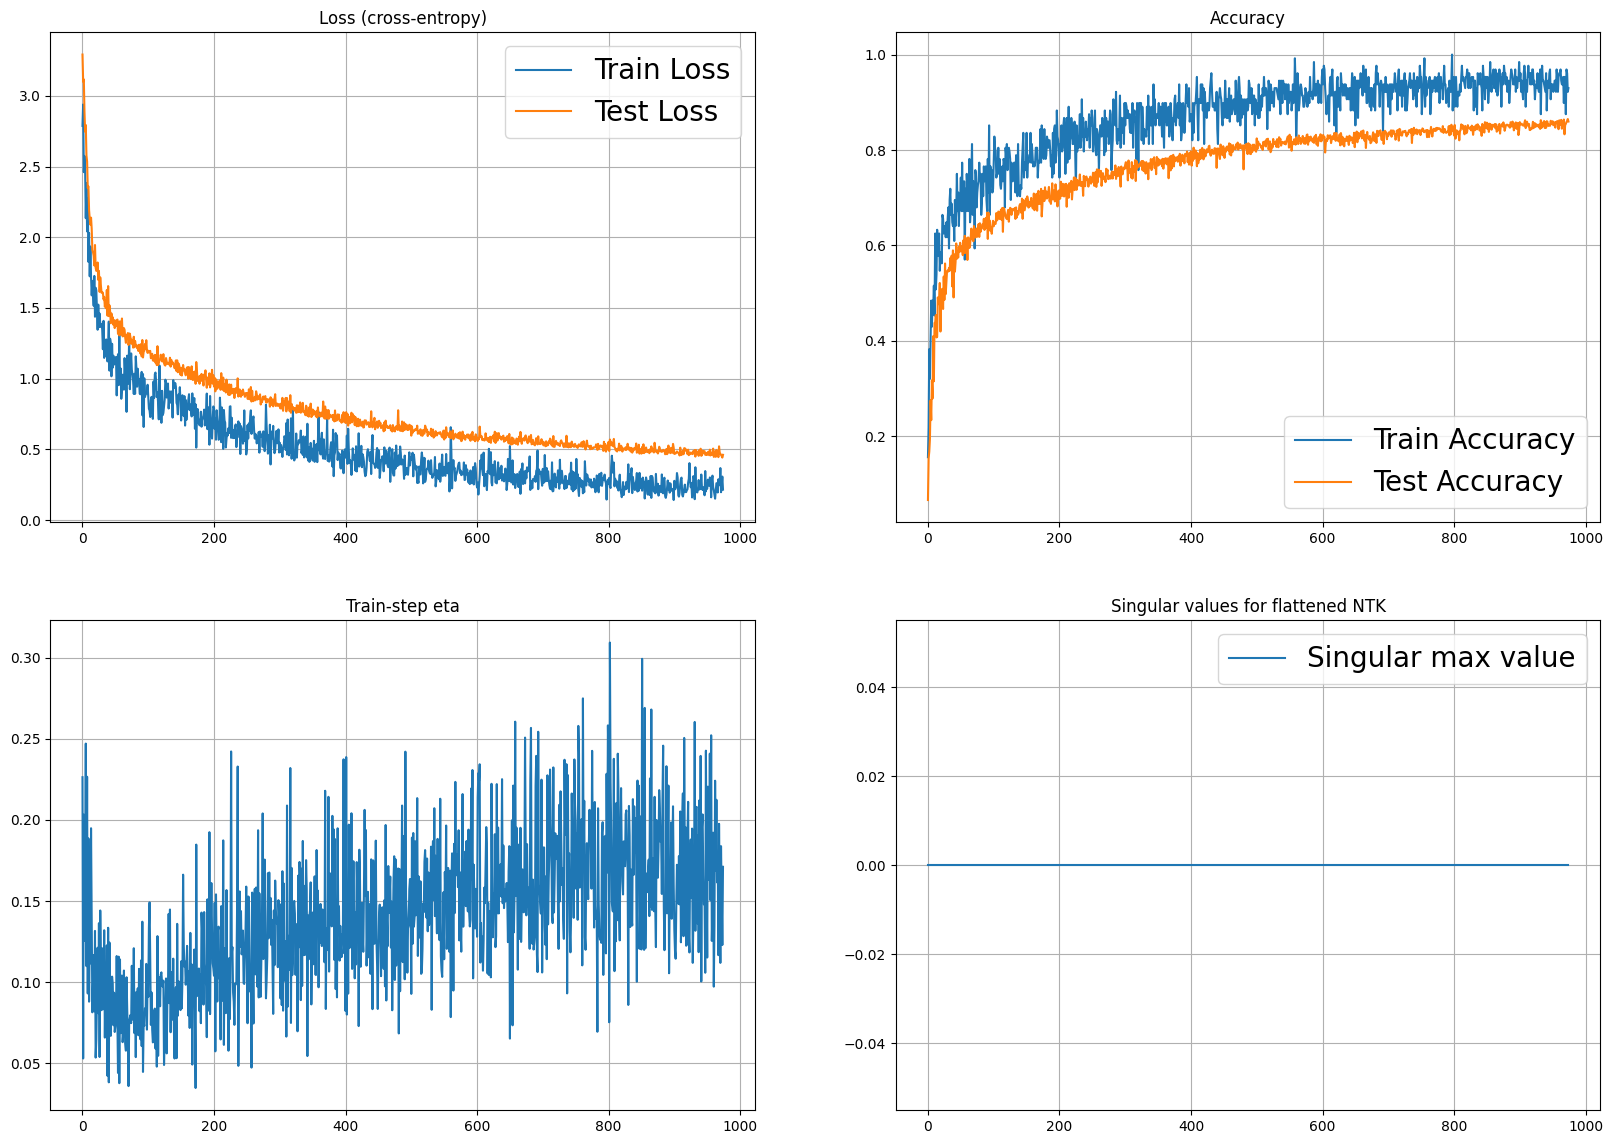

Test accuracy = 0.8596625766871165


In [17]:
stepCalcSoftmax = StepCalculatorEtaSoftmaxArmihoNorm2(meta)
stepCalcZh1 = StepCalculatorZhangLambda(meta)
for epoch in range(NUM_EPOCH):
    # training loop
    iter_number = 0
    for train_batch in train_dataloader:
        iter_number += 1
        images, labels_raw = train_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)
        with torch.no_grad():
            logits = testNet.forward_(xx)
            logits_detached = logits.detach().numpy()
            pp = labels_to_softhot(labels, meta.output_dim)
            qq = softmax(np.transpose(logits_detached), axis=(0))
            qq_active = reduce_to_active(qq, pp)

        qq_active_avg = np.average(qq_active)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}==--"\
                        .format(np.min(qq_active), np.max(qq_active), qq_active_avg))
        if qq_active_avg > 0.90:
            logging.info("##Step with Zhang optim")
            eta, logits_latest = stepCalcZh1.step(testNet, logits_detached, labels, xx)
        else:
            logging.info("##Step with norm2 optim")
            eta, logits_latest = stepCalcSoftmax.step(testNet, logits_detached, labels, xx)          
        logits_latest = logits_latest.detach()

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits_latest.numpy())
        prediction = logits_latest.argmax(dim=-1)
        loss = loss_crossentropy(zz_logits, labels)

        # save average train loss and accuracy
        HISTORY_PARAMS_ZH1['train_loss'].append(loss) #(train_loss_meter.avg)
        HISTORY_PARAMS_ZH1['train_accuracy'].append(calculate_accuracy(prediction,labels)) #(train_accuracy_meter.avg)
        HISTORY_PARAMS_ZH1['train_eta'].append(eta) #(eta_meter.avg)
        HISTORY_PARAMS_ZH1['train_ntk_sungular_max'].append(0) #(singular_meter.avg)

        # testing loop
        test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
        for test_batch in test_dataloader:
            images, labels_raw = test_batch
            labels = torch.tensor([x-1 for x in labels_raw])
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.no_grad():
                # do everything like we did in training loop
                batch_size = images.shape[0]
                xx = images.view(batch_size, -1)
                logits = testNet.forward_(xx)

                zz_logits = np.transpose(logits.detach().numpy())
                prediction = logits.argmax(dim=-1).detach()
                loss = loss_crossentropy(zz_logits, labels)
                test_loss_meter.update(loss)
                test_accuracy_meter.update(
                    calculate_accuracy(
                        prediction,
                        labels
                    )
                )

        # save average test accuracy loss and accuracy
        HISTORY_PARAMS_ZH1['test_loss'].append(test_loss_meter.avg)
        HISTORY_PARAMS_ZH1['test_accuracy'].append(test_accuracy_meter.avg)
        
        visualise(HISTORY_PARAMS_ZH1)
        print("Test accuracy = {}".format(test_accuracy_meter.avg))


#### Experiment 3

In [18]:
NEW_START = True
HISTORY_PARAMS2 = collections.defaultdict(list)

testNet = MNISTReLU(meta)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
if NEW_START:
    testNet.init_weights(cb, cw)
else:
    testNet.init_weights_txt('#current_saved/accuracy_eta_calculated')
    HISTORY_PARAMS2 = load_dict('#current_saved/accuracy_eta_calculated')
testNet.to(DEVICE)

FeedForwardNet created with n0=784, nk=0, nl=26, l=0, bias_on=True


MNISTReLU(
  (input_fc): Linear(in_features=784, out_features=1000, bias=True)
  (hidden_fc): Linear(in_features=1000, out_features=400, bias=True)
  (output_fc): Linear(in_features=400, out_features=26, bias=True)
)

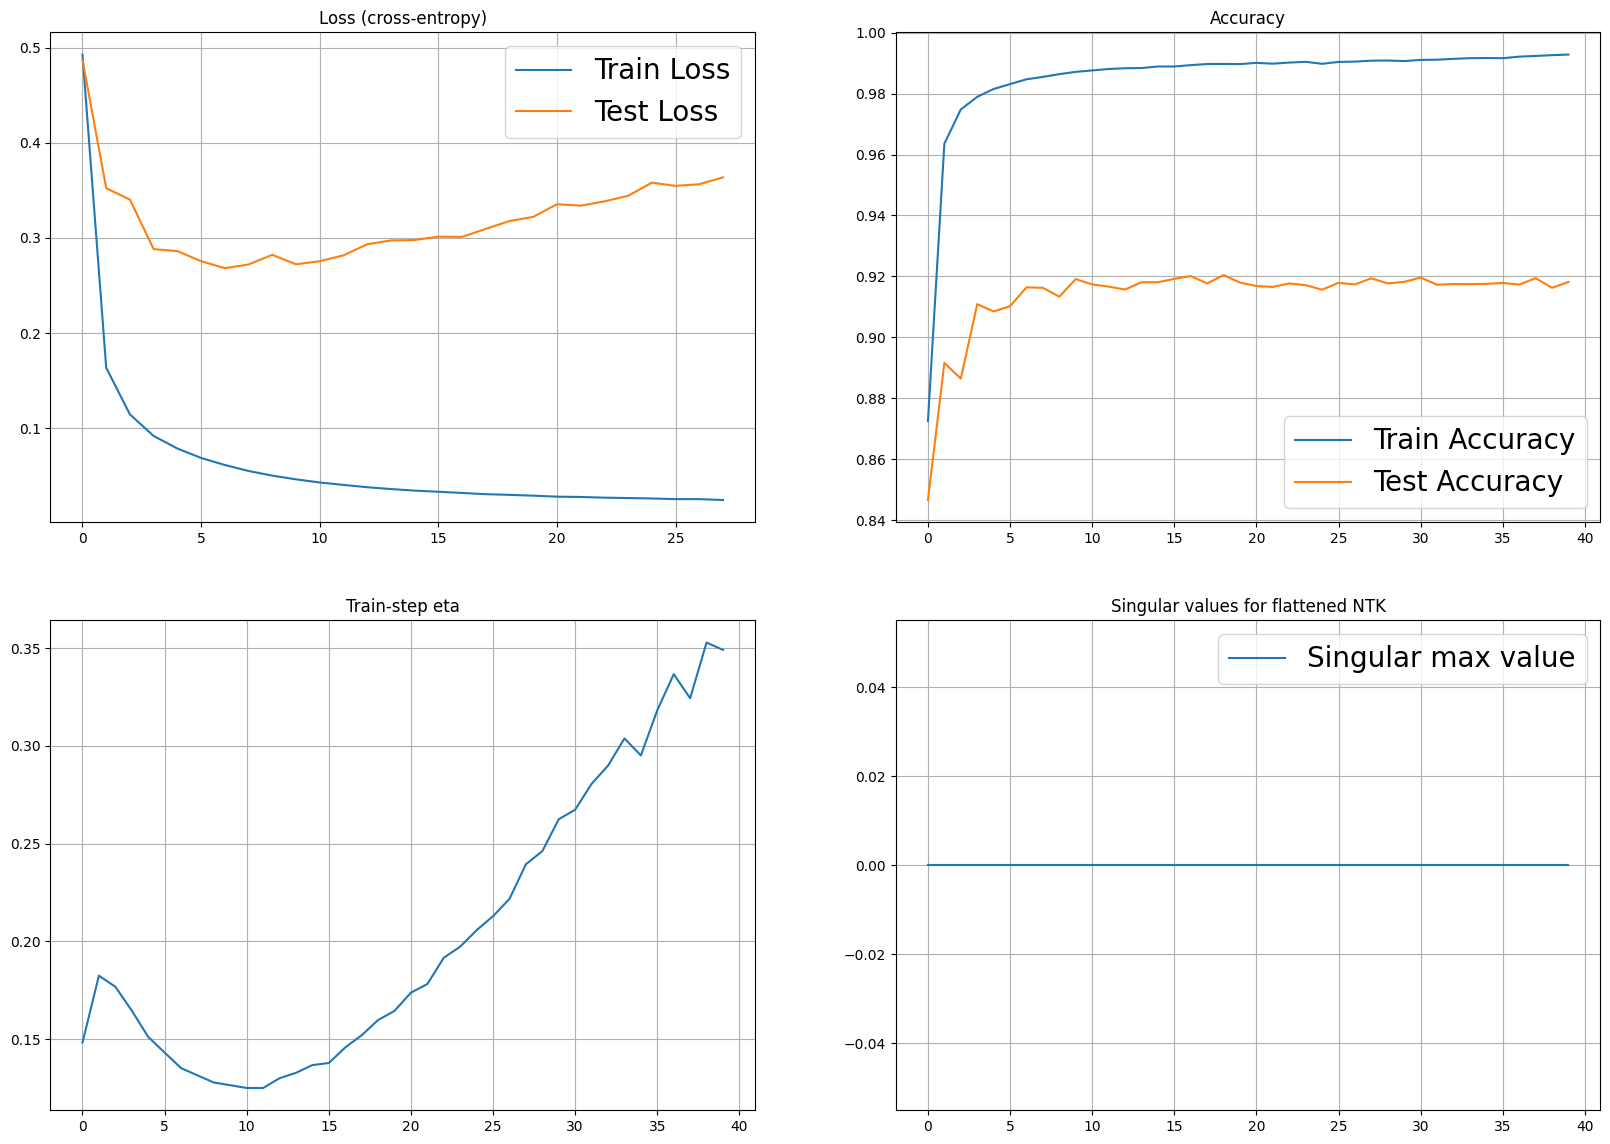

On epoch = 39 test accuracy = 0.9181844325153374


In [19]:
NUM_EPOCH = 40
stepCalc1 = StepCalculatorEtaSoftmaxArmihoNorm1(meta)
stepCalc2 = StepCalculatorEtaSoftmaxArmihoNorm2(meta)
stepZh = StepCalculatorZhangLambda(meta)

for epoch in range(NUM_EPOCH):
    # AverageMeter will accumulate average of some metric
    train_loss_meter, train_accuracy_meter, eta_meter = AverageMeter(), AverageMeter(), AverageMeter()
    # training loop
    iter_number = 0
    for train_batch in train_dataloader:
        iter_number += 1
        logging.info("\n --==epoch = {}, iter_number = {}==--".format(epoch, iter_number))
        images, labels_raw = train_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)

        with torch.no_grad():
            logits = testNet.forward_(xx)
            logits_detached = logits.detach().numpy()
            pp = labels_to_softhot(labels, meta.output_dim)
            qq = softmax(np.transpose(logits_detached), axis=(0))
            qq_active = reduce_to_active(qq, pp)

        qq_active_avg = np.average(qq_active)
        logging.info("##Initial qq for ones: min={}, max={}, avg={}"\
                        .format(np.min(qq_active), np.max(qq_active), qq_active_avg))
        if qq_active_avg > 0.9:
            logging.info("##Step with Zhang optim")
            eta, logits_latest = stepZh.step(testNet, logits_detached, labels, xx)
        else:
            logging.info("##Step with norm2 optim")
            eta, logits_latest = stepCalc2.step(testNet, logits_detached, labels, xx)
        logits_latest = logits_latest.detach()

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits_latest.numpy())
        prediction = logits_latest.argmax(dim=-1)
        loss = loss_crossentropy(zz_logits, labels)
        train_loss_meter.update(loss)
        train_accuracy_meter.update(calculate_accuracy(prediction,labels))
        eta_meter.update(eta)

    # save average train loss and accuracy
    HISTORY_PARAMS2['train_loss'].append(train_loss_meter.avg)
    HISTORY_PARAMS2['train_accuracy'].append(train_accuracy_meter.avg)
    HISTORY_PARAMS2['train_eta'].append(eta_meter.avg)
    HISTORY_PARAMS2['train_ntk_sungular_max'].append(0)

    # testing loop
    test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
    for test_batch in test_dataloader:
        images, labels_raw = test_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            # do everything like we did in training loop
            batch_size = images.shape[0]
            xx = images.view(batch_size, -1)
            logits = testNet.forward_(xx)

            zz_logits = np.transpose(logits.detach().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(
                calculate_accuracy(
                    prediction,
                    labels
                )
            )

    # save average test accuracy loss and accuracy
    HISTORY_PARAMS2['test_loss'].append(test_loss_meter.avg)
    HISTORY_PARAMS2['test_accuracy'].append(test_accuracy_meter.avg)
    
    visualise(HISTORY_PARAMS2)
    print("On epoch = {} test accuracy = {}".format(epoch, test_accuracy_meter.avg))    


    #if iter_number >= 10:
    testNet.save_txt('#current_saved/accuracy_eta_calculated')
    save_dict(HISTORY_PARAMS2, '#current_saved/accuracy_eta_calculated')
    iter_number = 0



In [20]:
HISTORY_PARAMS2['test_accuracy']

[0.8466257668711656,
 0.891631518404908,
 0.8864551380368099,
 0.9108991564417178,
 0.9085026840490797,
 0.9102281441717791,
 0.9164110429447853,
 0.916267254601227,
 0.9133435582822086,
 0.9191430214723927,
 0.9173696319018405,
 0.9166506901840491,
 0.9156921012269938,
 0.9180885736196319,
 0.9180885736196319,
 0.9191909509202454,
 0.9201016104294478,
 0.9177051380368099,
 0.9204371165644172,
 0.9179927147239264,
 0.9168424079754601,
 0.9165548312883436,
 0.9177051380368099,
 0.9171299846625767,
 0.9156441717791411,
 0.9178968558282209,
 0.9173696319018405,
 0.9193826687116564,
 0.9177051380368099,
 0.9182323619631901,
 0.9196223159509203,
 0.917273773006135,
 0.9175134202453987,
 0.917465490797546,
 0.9175613496932515,
 0.9178489263803681,
 0.9173217024539877,
 0.9194305981595092,
 0.916267254601227,
 0.9181844325153374]

In [21]:
print("Accuracy achieved in FFN at Relu-criticality: "+str(HISTORY_PARAMS2['test_accuracy'][-1]))

Accuracy achieved in FFN at Relu-criticality: 0.9181844325153374


In [22]:
NEW_START = True
HISTORY_PARAMS3 = collections.defaultdict(list)

testNet = MNISTReLU(meta)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
if NEW_START:
    testNet.init_weights(cb, cw)
else:
    testNet.init_weights_txt('#current_saved/accuracy_eta_calculated')
    HISTORY_PARAMS3 = load_dict('#current_saved/accuracy_eta_calculated')
testNet.to(DEVICE)

FeedForwardNet created with n0=784, nk=0, nl=26, l=0, bias_on=True


MNISTReLU(
  (input_fc): Linear(in_features=784, out_features=1000, bias=True)
  (hidden_fc): Linear(in_features=1000, out_features=400, bias=True)
  (output_fc): Linear(in_features=400, out_features=26, bias=True)
)

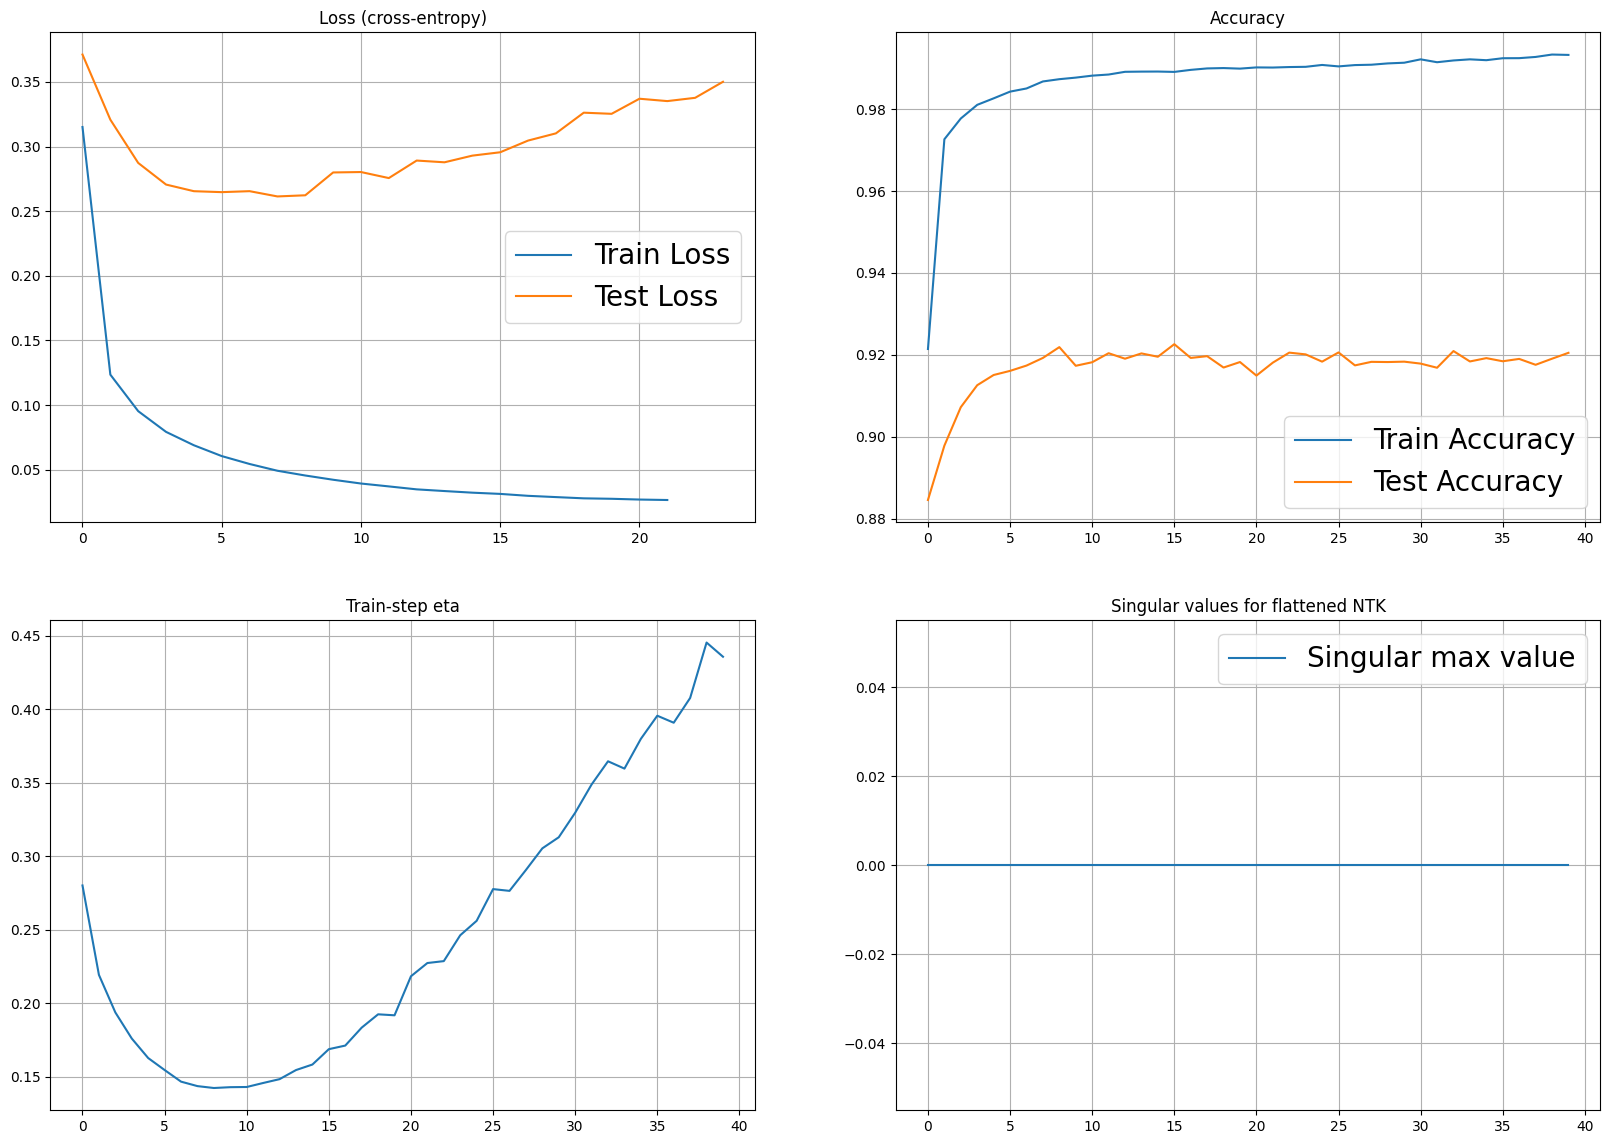

On epoch = 39 test accuracy = 0.92048504601227


In [23]:
NUM_EPOCH = 40
stepCalc1 = StepCalculatorEtaSoftmaxArmihoNorm1(meta)
stepCalc2 = StepCalculatorEtaSoftmaxArmihoNorm2(meta)
stepZh = StepCalculatorZhangLambda(meta)
stepZhSimpl = StepCalculatorZhangSimplified(meta)

for epoch in range(NUM_EPOCH):
    # AverageMeter will accumulate average of some metric
    train_loss_meter, train_accuracy_meter, eta_meter = AverageMeter(), AverageMeter(), AverageMeter()
    # training loop
    iter_number = 0
    for train_batch in train_dataloader:
        iter_number += 1
        logging.info("\n --==epoch = {}, iter_number = {}==--".format(epoch, iter_number))
        images, labels_raw = train_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)

        with torch.no_grad():
            logits = testNet.forward_(xx)
            logits_detached = logits.detach().numpy()
            pp = labels_to_softhot(labels, meta.output_dim)
            qq = softmax(np.transpose(logits_detached), axis=(0))
            qq_active = reduce_to_active(qq, pp)

        qq_active_avg = np.average(qq_active)
        logging.info("##Initial qq for ones: min={}, max={}, avg={}"\
                        .format(np.min(qq_active), np.max(qq_active), qq_active_avg))
        if qq_active_avg > 0.0000000008:
            logging.info("##Step with Zhang optim")
            eta, logits_latest = stepZh.step(testNet, logits_detached, labels, xx)
        else:
            logging.info("##Step with norm2 optim")
            eta, logits_latest = stepCalc2.step(testNet, logits_detached, labels, xx)
        logits_latest = logits_latest.detach()

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits_latest.numpy())
        prediction = logits_latest.argmax(dim=-1)
        loss = loss_crossentropy(zz_logits, labels)
        train_loss_meter.update(loss)
        train_accuracy_meter.update(calculate_accuracy(prediction,labels))
        eta_meter.update(eta)

    # save average train loss and accuracy
    HISTORY_PARAMS3['train_loss'].append(train_loss_meter.avg)
    HISTORY_PARAMS3['train_accuracy'].append(train_accuracy_meter.avg)
    HISTORY_PARAMS3['train_eta'].append(eta_meter.avg)
    HISTORY_PARAMS3['train_ntk_sungular_max'].append(0)

    # testing loop
    test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
    for test_batch in test_dataloader:
        images, labels_raw = test_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            # do everything like we did in training loop
            batch_size = images.shape[0]
            xx = images.view(batch_size, -1)
            logits = testNet.forward_(xx)

            zz_logits = np.transpose(logits.detach().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(
                calculate_accuracy(
                    prediction,
                    labels
                )
            )

    # save average test accuracy loss and accuracy
    HISTORY_PARAMS3['test_loss'].append(test_loss_meter.avg)
    HISTORY_PARAMS3['test_accuracy'].append(test_accuracy_meter.avg)
    
    visualise(HISTORY_PARAMS3)
    print("On epoch = {} test accuracy = {}".format(epoch, test_accuracy_meter.avg))    


    #if iter_number >= 10:
    testNet.save_txt('#current_saved/accuracy_eta_calculated')
    save_dict(HISTORY_PARAMS3, '#current_saved/accuracy_eta_calculated')
    iter_number = 0



#### FFN as a reference implementation

In [24]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
                
        self.input_fc = nn.Linear(input_dim, INPUT_WIDTH)
        self.hidden_fc = nn.Linear(INPUT_WIDTH, HIDDEN_WIDTH)
        self.output_fc = nn.Linear(HIDDEN_WIDTH, output_dim)
        
    def forward(self, x):
        #x = [batch size, height, width]
        batch_size = x.shape[0]
        x = x.view(batch_size, -1)
        #x = [batch size, height * width]
        h_1 = F.relu(self.input_fc(x))
        #h_1 = [batch size, 250]
        h_2 = F.relu(self.hidden_fc(h_1))
        #h_2 = [batch size, 100]
        y_pred = self.output_fc(h_2)
        #y_pred = [batch size, output dim]
        return y_pred, h_2

### YOUR SOLUTION ###
model2 = MLP(INPUT_DIM, OUTPUT_DIM)

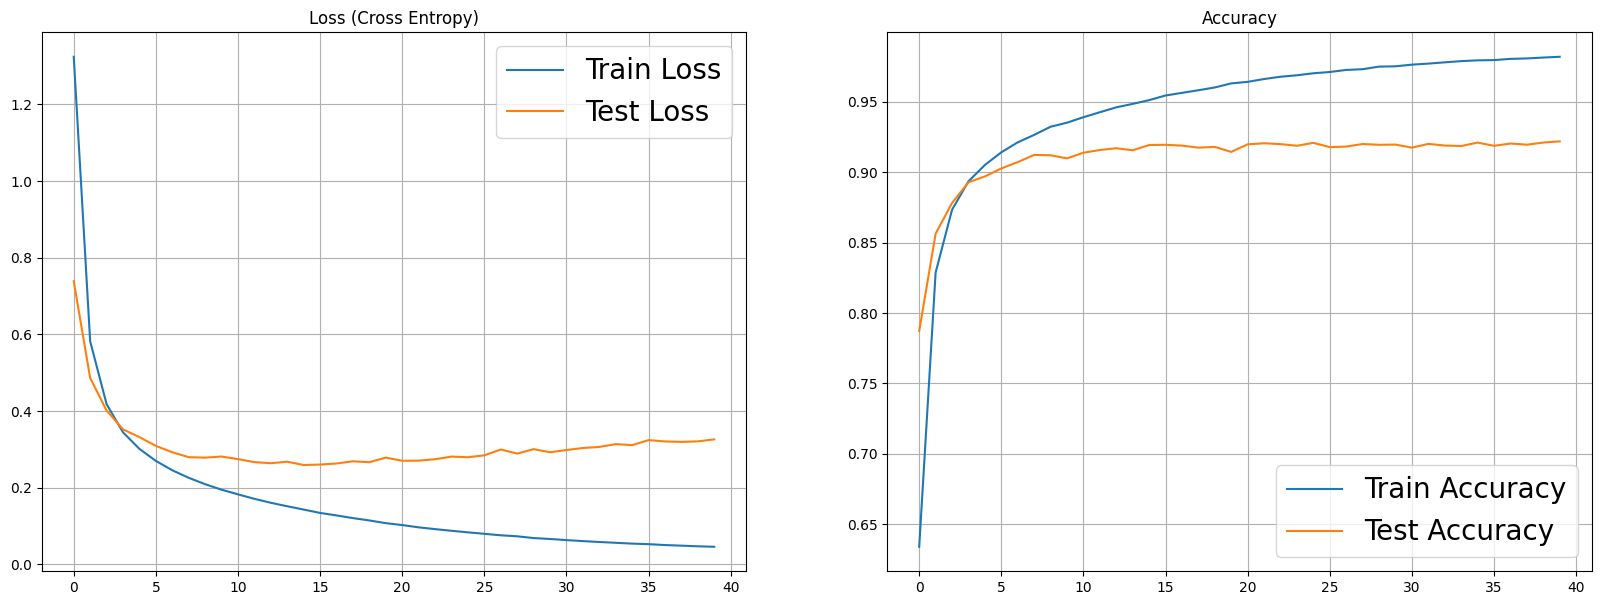

In [25]:
NUM_EPOCH = 40
HISTORY_NONCRITICALITY = collections.defaultdict(list)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model2.parameters(), lr=1e-2, momentum=0.9, nesterov=True)

DEVICE = torch.device('cpu')  # you can change to `cuda:0`
model2.to(DEVICE)

for epoch in range(NUM_EPOCH):
    # AverageMeter will accumulate average of some metric
    # Procceed to `utils.py` to see implementation
    train_loss_meter = AverageMeter()
    train_accuracy_meter = AverageMeter()
    test_loss_meter = AverageMeter()
    test_accuracy_meter = AverageMeter()
    
    # training loop
    for train_batch in train_dataloader:
        
        # unpack batch and move to specific device (for example, GPU or TPU)
        images, labels_raw = train_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        logits, _ = model2.forward(images)
        prediction = logits.argmax(dim=-1)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # calculate current average loss and accuracy
        train_loss_meter.update(loss.item())
        train_accuracy_meter.update(
            calculate_accuracy(
                prediction.detach(),
                labels
            )
        )
    #break
    # save average train loss and accuracy
    HISTORY_NONCRITICALITY['train_loss'].append(train_loss_meter.avg)
    HISTORY_NONCRITICALITY['train_accuracy'].append(train_accuracy_meter.avg)
        
    # testing loop
    for test_batch in test_dataloader:
        images, labels_raw = test_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        # аdd `with torch.no_grad()' to avoid computing gradients of weights
        with torch.no_grad():
            # do everything like we did in training loop
            logits, _ = model2(images)
            prediction = logits.argmax(dim=-1)
            loss = criterion(logits, labels)
        
        test_loss_meter.update(loss.item())
        test_accuracy_meter.update(
            calculate_accuracy(
                prediction,
                labels
            )
        )
    
    # save average test accuracy loss and accuracy
    HISTORY_NONCRITICALITY['test_loss'].append(test_loss_meter.avg)
    HISTORY_NONCRITICALITY['test_accuracy'].append(test_accuracy_meter.avg)
    
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    axes[0].set_title('Loss (Cross Entropy)')
    axes[0].plot(HISTORY_NONCRITICALITY['train_loss'], label='Train Loss')
    axes[0].plot(HISTORY_NONCRITICALITY['test_loss'], label='Test Loss')
    axes[0].grid()
    axes[0].legend(fontsize=20)
    
    axes[1].set_title('Accuracy')
    axes[1].plot(HISTORY_NONCRITICALITY['train_accuracy'], label='Train Accuracy')
    axes[1].plot(HISTORY_NONCRITICALITY['test_accuracy'], label='Test Accuracy')
    axes[1].grid()
    axes[1].legend(fontsize=20)
    
    plt.show()

In [26]:
print("Accuracy achieved in FFN at Relu-criticality: "+str(HISTORY_NONCRITICALITY['test_accuracy'][-1]))

Accuracy achieved in FFN at Relu-criticality: 0.9217791411042945


In [27]:
HISTORY_NONCRITICALITY['test_accuracy']

[0.7871932515337423,
 0.8562595858895705,
 0.878019555214724,
 0.8927338957055214,
 0.8969037576687117,
 0.9025594325153374,
 0.9070648006134969,
 0.9121453220858896,
 0.9119056748466258,
 0.9097009202453987,
 0.9137269938650306,
 0.9156441717791411,
 0.9168903374233128,
 0.91545245398773,
 0.9191909509202454,
 0.9193347392638037,
 0.9187595858895705,
 0.9173217024539877,
 0.9178489263803681,
 0.9143021472392638,
 0.919670245398773,
 0.9204371165644172,
 0.9198140337423313,
 0.918663726993865,
 0.9207246932515337,
 0.9177051380368099,
 0.9180885736196319,
 0.9199098926380368,
 0.9193347392638037,
 0.9194785276073619,
 0.9173217024539877,
 0.9200057515337423,
 0.9188075153374233,
 0.918472009202454,
 0.9209164110429447,
 0.9186157975460123,
 0.9202453987730062,
 0.9194305981595092,
 0.9209164110429447,
 0.9217791411042945]

#### Relu at criticality

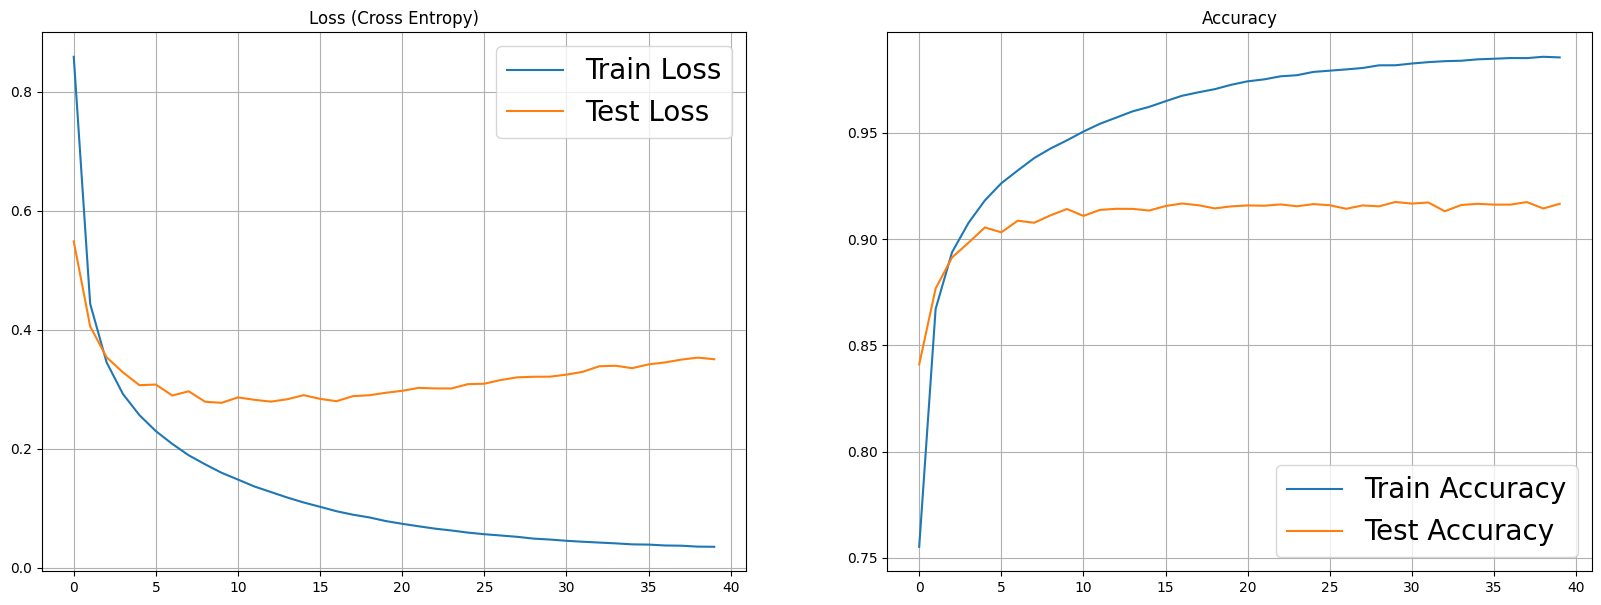

In [28]:
NUM_EPOCH = 40
HISTORY_CRITICALITY = collections.defaultdict(list)

testNet = MNISTReLU(meta)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
testNet.init_weights(cb, cw)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(testNet.parameters(), lr=1e-2, momentum=0.9, nesterov=True) #, momentum=0.9, nesterov=True)

DEVICE = torch.device('cpu')  # you can change to `cuda:0`
testNet.to(DEVICE)

for epoch in range(NUM_EPOCH):
    # AverageMeter will accumulate average of some metric
    # Check implementation in `utils.py`
    train_loss_meter, train_accuracy_meter, test_loss_meter, test_accuracy_meter = \
        AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()
    
    # training loop
    for train_batch in train_dataloader:
        
        # unpack batch and move to specific device (for example, GPU or TPU)
        images, labels_raw = train_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)
        logits = testNet.forward_(xx)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        #testNet.output_fc.backward()
        optimizer.step()

        prediction = logits.argmax(dim=-1)
        # calculate current average loss and accuracy
        train_loss_meter.update(loss.item())
        train_accuracy_meter.update(
            calculate_accuracy(
                prediction.detach(),
                labels
            )
        )
    #break
    # save average train loss and accuracy
    HISTORY_CRITICALITY['train_loss'].append(train_loss_meter.avg)
    HISTORY_CRITICALITY['train_accuracy'].append(train_accuracy_meter.avg)
        
    # testing loop
    for test_batch in test_dataloader:
        images, labels_raw = test_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        # аdd `with torch.no_grad()' to avoid computing gradients of weights
        with torch.no_grad():
            # do everything like we did in training loop
            batch_size = images.shape[0]
            xx = images.view(batch_size, -1)
            logits = testNet.forward_(xx)            
            prediction = logits.argmax(dim=-1)
            loss = criterion(logits, labels)
        
        test_loss_meter.update(loss.item())
        test_accuracy_meter.update(
            calculate_accuracy(
                prediction,
                labels
            )
        )
    
    # save average test accuracy loss and accuracy
    HISTORY_CRITICALITY['test_loss'].append(test_loss_meter.avg)
    HISTORY_CRITICALITY['test_accuracy'].append(test_accuracy_meter.avg)
    
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    axes[0].set_title('Loss (Cross Entropy)')
    axes[0].plot(HISTORY_CRITICALITY['train_loss'], label='Train Loss')
    axes[0].plot(HISTORY_CRITICALITY['test_loss'], label='Test Loss')
    axes[0].grid()
    axes[0].legend(fontsize=20)
    
    axes[1].set_title('Accuracy')
    axes[1].plot(HISTORY_CRITICALITY['train_accuracy'], label='Train Accuracy')
    axes[1].plot(HISTORY_CRITICALITY['test_accuracy'], label='Test Accuracy')
    axes[1].grid()
    axes[1].legend(fontsize=20)
    
    plt.show()

#### Comparison

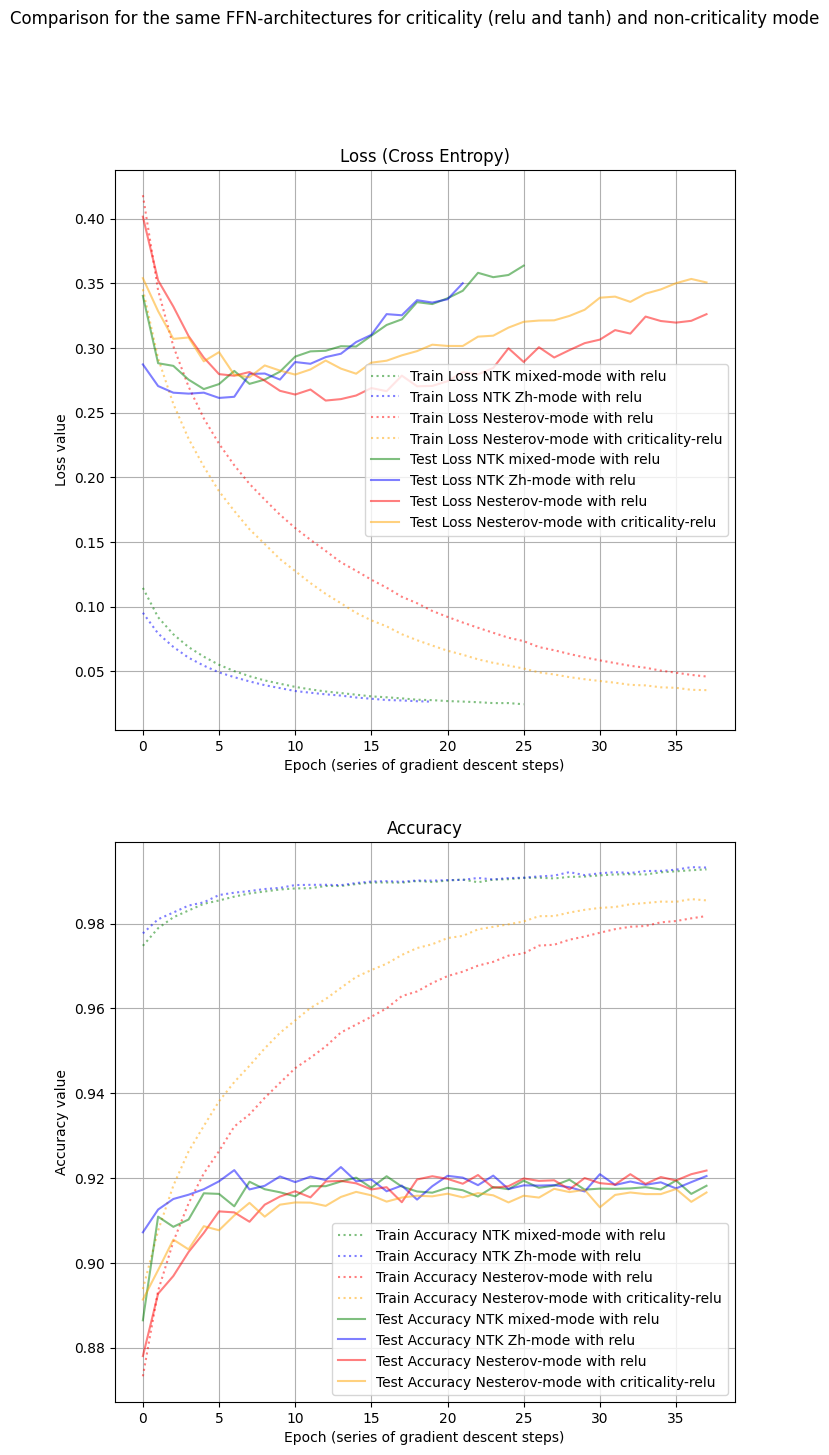

In [29]:
#start_epoch, finish_epoch = 10, 20
display.clear_output()
fig, axes = plt.subplots(2, 1, figsize=(8, 16))
axes[0].set_title('Loss (Cross Entropy)')
#axes[0].set_xlim(start_epoch-1, finish_epoch)
axes[0].plot(HISTORY_PARAMS2['train_loss'][2:40], color='g', ls='dotted', alpha=.5, label='Train Loss NTK mixed-mode with relu')
axes[0].plot(HISTORY_PARAMS3['train_loss'][2:40], color='b', ls='dotted', alpha=.5, label='Train Loss NTK Zh-mode with relu')
axes[0].plot(HISTORY_NONCRITICALITY['train_loss'][2:40], color='r', ls='dotted', alpha=.5, label='Train Loss Nesterov-mode with relu')
axes[0].plot(HISTORY_CRITICALITY['train_loss'][2:40], color='orange', ls='dotted', alpha=.5, label='Train Loss Nesterov-mode with criticality-relu')
axes[0].plot(HISTORY_PARAMS2['test_loss'][2:40], color='g', alpha=.5, label='Test Loss NTK mixed-mode with relu')
axes[0].plot(HISTORY_PARAMS3['test_loss'][2:40], color='b', alpha=.5, label='Test Loss NTK Zh-mode with relu')
axes[0].plot(HISTORY_NONCRITICALITY['test_loss'][2:40], color='r', alpha=.5, label='Test Loss Nesterov-mode with relu')
axes[0].plot(HISTORY_CRITICALITY['test_loss'][2:40], color='orange', alpha=.5, label='Test Loss Nesterov-mode with criticality-relu')
axes[0].grid()
axes[0].legend()
axes[0].set_xlabel("Epoch (series of gradient descent steps)")
axes[0].set_ylabel("Loss value")

axes[1].set_title('Accuracy')
#axes[1].set_xlim(10, 20)
axes[1].plot(HISTORY_PARAMS2['train_accuracy'][2:40], color='g', alpha=.5, ls='dotted', label='Train Accuracy NTK mixed-mode with relu')
axes[1].plot(HISTORY_PARAMS3['train_accuracy'][2:40], color='b', alpha=.5, ls='dotted', label='Train Accuracy NTK Zh-mode with relu')
axes[1].plot(HISTORY_NONCRITICALITY['train_accuracy'][2:40], color='r', alpha=.5, ls='dotted', label='Train Accuracy Nesterov-mode with relu')
axes[1].plot(HISTORY_CRITICALITY['train_accuracy'][2:40], color='orange', alpha=.5, ls='dotted', label='Train Accuracy Nesterov-mode with criticality-relu')
axes[1].plot(HISTORY_PARAMS2['test_accuracy'][2:40], color='g', alpha=.5, label='Test Accuracy NTK mixed-mode with relu')
axes[1].plot(HISTORY_PARAMS3['test_accuracy'][2:40], color='b', alpha=.5, label='Test Accuracy NTK Zh-mode with relu')
axes[1].plot(HISTORY_NONCRITICALITY['test_accuracy'][2:40], color='r', alpha=.5, label='Test Accuracy Nesterov-mode with relu')
axes[1].plot(HISTORY_CRITICALITY['test_accuracy'][2:40], color='orange', alpha=.5, label='Test Accuracy Nesterov-mode with criticality-relu')
axes[1].grid()
axes[1].legend()
axes[1].set_xlabel("Epoch (series of gradient descent steps)")
axes[1].set_ylabel("Accuracy value")

#fig.tight_layout()
#fig.subplots_adjust(top=0.95)
dummy=fig.suptitle("Comparison for the same FFN-architectures for criticality (relu and tanh) and non-criticality mode")

plt.show()